# Coupled two-node mean-field brain network analysis

In this Notebook, the coupled two-node system is analyzed to understand the nature of the fixed points using Jacobian Matrix evaluated at them.

### Objectives

1. Analyze how mean-field neuronal firing heterogeneity affects the network stability using fixed point analysis.

### Model simplications

For this analysis, the following simplest model analysis scenarios are considered:
1. both nodes and their sub-populations will have same heterogeneity para i.e., $\sigma_e^1 = \sigma_i^1 = \sigma_e^2 = \sigma_i^2 = \sigma$
2. both nodes will have same heterogeneity paras but differentiate between sub-populations: $\sigma_x^1 = = \sigma_x^2 = \sigma_x$ where x = {e, i}
3. system will be qualitatively analyzed using time series for selected perturbations of ($\sigma_e^1, \sigma_i^1, \sigma_e^2, \sigma_i^2$)
4. either have active vs. passive nodes or have both being applied the same external input (at E-populations)
   
### Outputs to produce

1. $\sigma^1$ vs. $\sigma^2$ (both sub-pop will have same $\sigma$ but changed between nodes)
2. $\sigma_e$ vs. $\sigma_i$ (both nodes will have same $\sigma$ values for sub-pop but differentiated between sub-pops)
3. K vs. $\sigma$ (both nodes and sub-pop will have same $\sigma$)
4. K vs. $\sigma_e$ vs. $\sigma_i$ (both nodes will have same $\sigma$ values for sub-pop)
5. K vs. $\sigma^1$ vs. $\sigma^2$ (both sub-pops will have same $\sigma$ values but changed between nodes)
7. Jacobian evaluation with above simplified modeling assumptions
8. time series for selected perturbations of ($\sigma_e^1, \sigma_i^1, \sigma_e^2, \sigma_i^2$, K)


In [2]:
import os
import json
import time
import random
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt

from scipy import signal, linalg
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
from tqdm import  tqdm

from utils import *
from plot_utils import *
from measure_utils import *

%matplotlib inline
plt.rcParams.update({'font.size': 16})

In [3]:
COLOR_MAP = {
                'mediumblue': "Unstable Node",
                'darkgreen': "Stable Node",
                'red': "Unstable Saddle Point",
                'saddlebrown': "Stable Spiral",
                'purple': "Unstable Spiral",
                'black': "Circle"
            }

In [4]:
# Setting save dir paths
root_dir = "./sv_coupled_model"

save_str = datetime.datetime.now()
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}-fp"

save_dir = os.path.join(root_dir, sub_dir)

print(f"Creating dir to save results:: {save_dir}")
os.makedirs(save_dir, exist_ok = True)

write_json = {}

Creating dir to save results:: ./sv_coupled_model\exp-2023-11-13-fp


In [5]:
# defining parameters
params = dict()

params['gamma'] = 0.016

params['sig_e1'] = params['sig_e2'] = 4.4
params['sig_i1'] = params['sig_i2'] = 16.5

params['K'] = 0.2
params['D'] = 0.001
params['dt'] = 0.1
params['Ne'] = 800
params['Ni'] = 200

params['beta'] = 300 * params['gamma']
params['theta'] = 0.0
params['tau_e'] = 1
params['tau_i'] = 1 / 2

params['wee'] = 1.6 / params['gamma']
params['wei'] = 3.0 / params['gamma']
params['wie'] = -4.7 / params['gamma']
params['wii'] = -0.13 / params['gamma']

params['i_e1'] = 0.25 / params['gamma']
params['i_i1'] = -0.5 / params['gamma']
params['i_e2'] = -0.25 / params['gamma']
params['i_i2'] = -0.5 / params['gamma']

In [6]:
T = 2500
time_ = np.arange(0, T)

# grid parameters
minval = -1 / params['gamma']
maxval = 1 / params['gamma']
grid_res = 20
n_trials = 5

# Initialization points
x0_ = np.random.uniform(minval, maxval, n_trials)
x1_ = np.random.uniform(minval, maxval, n_trials)
x2_ = np.random.uniform(minval, maxval, n_trials)
x3_ = np.random.uniform(minval, maxval, n_trials)

In [7]:
# init image counts
ts_image_count = 0

In [8]:
def euler_intergrate(u, **opts):
    # common parameters
    beta = opts.get('beta')
    gamma = opts.get('gamma')
    theta = opts.get('theta')

    for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
            # initialize with the points
            u[k, :, 0] = y0
            for t in range(T - 1):
                u[k, 0, t + 1] = u[k, 0, t] + opts.get('dt') / opts.get('tau_e') * \
                                 (-u[k, 0, t] + opts.get('wee') * F(u[k, 0, t], beta, theta, gamma, opts.get('sig_e1')) + \
                                  opts.get('wie') * F(u[k, 1, t], beta, theta, gamma, opts.get('sig_i1')) + \
                                  opts.get('i_e1') + opts.get('K') * u[k, 2, t])
                
                u[k, 1, t + 1] = u[k, 1, t] + opts.get('dt') / opts.get('tau_i') * \
                                 (-u[k, 1, t] + opts.get('wei') * F(u[k, 0, t], beta, theta, gamma, opts.get('sig_e1')) + \
                                  opts.get('wii') * F(u[k, 1, t], beta, theta, gamma, opts.get('sig_i1')) + opts.get('i_i1'))
                
                u[k, 2, t + 1] = u[k, 2, t] + opts.get('dt') / opts.get('tau_e') * \
                                 (-u[k, 2, t] + opts.get('wee') * F(u[k, 2, t], beta, theta, gamma, opts.get('sig_e2')) + \
                                  opts.get('wie') * F(u[k, 3, t], beta, theta, gamma, opts.get('sig_i2')) + \
                                  opts.get('i_e2') + opts.get('K') * u[k, 0, t]
                                  )
                
                u[k, 3, t + 1] = u[k, 3, t] + opts.get('dt') / opts.get('tau_i') * \
                                 (-u[k, 3, t] + opts.get('wei') * F(u[k, 2, t], beta, theta, gamma, opts.get('sig_e2')) + \
                                  opts.get('wii') * F(u[k, 3, t], beta, theta, gamma, opts.get('sig_i2')) + opts.get('i_i2')
                                  )
    return u

In [9]:
t_start = 200
t_end = T

## Scenario 01 - assume the $\sigma_x^l = \sigma$ for $x \in \{e, i\}$ and $l = 1, 2$

In [10]:
# fixed-point projections - how system dynamics at the fixed points behaves with coupling value

eval_sigma_values = [2.5, 4.4, 7.8, 16.5]
params['i_e1'] = -0.1 / params.get('gamma')

k_min = -1; k_max = 1; k_steps = 500
k_values = k_min + np.arange(0, k_steps) / k_steps * (k_max - k_min)

plot_dict = {'fig_size': (10, 10), 'xlabel': r"$K$", 'var_name': 'coupling value', 
             'd_var_str': r"($\sigma_e^1 = \sigma_i^1 = \sigma_e^2 = \sigma_i^2$ = " + f"{params.get('sig_e1')}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV)"
             }

for sigma in eval_sigma_values:
    params['sig_e1'] = params['sig_e2'] = params['sig_i1'] = params['sig_i2'] = sigma 
    
    plot_dict = {'fig_size': (10, 10), 'xlabel': r"$K$", 'var_name': 'coupling value', 
             'd_var_str': r"($\sigma_e^1 = \sigma_i^1 = \sigma_e^2 = \sigma_i^2$ = " + f"{params.get('sig_e1')}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV)"
             }
    
    fp_var = []
    fp_arr = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
    fp_types = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
    
    file_str_k = f"scenario_1_sigma_{params['sig_e1']:.3f}_ie1_{params['i_e1']:.3f}mV"
    file_name = os.path.join(save_dir, file_str_k + '.pkl')
    
    if os.path.isfile(file_name):
        print(f"file found at {file_name}! loading results...")
        plot_fps = pickle.load(open(file_name, 'rb'))
    
    else:
        print("File is not found! Running the analysis...")
        for i in tqdm(range(len(k_values))):
            # print(f"Coupling Strength :: {k:.3f}")
            params['K'] = k_values[i]
            fp_dict = calc_fixed_points( minval = minval, maxval = maxval, grid_res = grid_res, n_init = 20, cal_grad = False, **params)
            eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
            
            fps = fp_dict['fps'].T   
            fp_type = eig_dict['types']
    
            if len(fp_type) == 0:
                continue
                
            for fp, fp_color in zip(fps, fp_type):
                fp_var.append(k_values[i])
                fp_arr['ue1'].append(fp[0]); fp_arr['ui1'].append(fp[1]); fp_arr['ue2'].append(fp[2]); fp_arr['ui2'].append(fp[3])
                fp_types['ue1'].append(fp_color); fp_types['ui1'].append(fp_color); fp_types['ue2'].append(fp_color); fp_types['ui2'].append(fp_color)
    
        plot_fps = {'fp_var': fp_var, 'fps': fp_arr, 'fp_types': fp_types }
    
        with open(file_name, 'wb') as file:
            pickle.dump(plot_fps, file)
    
    plot_fp_projections(plot_fps_dict = plot_fps, plot_dict = plot_dict, save_dir = save_dir, if_save = True, image_name = file_str_k, **params)

File is not found! Running the analysis...


  0%|          | 0/500 [00:00<?, ?it/s]C:\Users\kgaya\OneDrive - University of Toronto\University of Toronto\MASc Research Project\#03 Implementation\Heterogeneity Spike Model\SVSystemAnalysis\sv_two_node_analysis\utils.py:19: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * (x - thresh)))
C:\Users\kgaya\OneDrive - University of Toronto\University of Toronto\MASc Research Project\#03 Implementation\Heterogeneity Spike Model\SVSystemAnalysis\sv_two_node_analysis\utils.py:138: RuntimeWarning: overflow encountered in square
  return beta * np.exp(-beta * (x - theta)) / ((1 + np.exp(-beta * (x - theta))) ** 2)
  3%|▎         | 15/500 [00:10<05:54,  1.37it/s]


KeyboardInterrupt: 

In [ ]:
# fixed-point projections - how system dynamics at the fixed points behaves with input value

eval_sigma_values = [2.5, 4.4, 7.8, 16.5]
params['K'] = 0.2

i_min = -0.25; i_max = 0.25; i_steps = 500
i_values = i_min + np.arange(0, i_steps) / i_steps * (i_max - i_min)

for sigma in eval_sigma_values:
    params['sig_e1'] = params['sig_e2'] = params['sig_i1'] = params['sig_i2'] = sigma 
    
    plot_dict = {'fig_size': (10, 10), 'xlabel': r"$I_{in}^1$", 'var_name': 'external stimulus', 
             'd_var_str': r"($\sigma_e^1 = \sigma_i^1 = \sigma_e^2 = \sigma_i^2$ = " + f"{params.get('sig_e1')}, " + r"$K = $" + f"{params['K']:.3f})"
             }
    
    fp_var = []
    fp_arr = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
    fp_types = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
    
    file_str_k = f"scenario_1_sigma_{params['sig_e1']:.3f}_K_{params['K']:.3f}"
    file_name = os.path.join(save_dir, file_str_k + '.pkl')
    
    if os.path.isfile(file_name):
        print(f"file found at {file_name}! loading results...")
        plot_fps = pickle.load(open(file_name, 'rb'))
    
    else:
        print("File is not found! Running the analysis...")
        for i in tqdm(range(len(i_values))):
            params['i_e1'] = i_values[i] / params['gamma']
            fp_dict = calc_fixed_points( minval = minval, maxval = maxval, grid_res = grid_res, n_init = 20, cal_grad = False, **params)
            eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
            
            fps = fp_dict['fps'].T   
            fp_type = eig_dict['types']
    
            if len(fp_type) == 0:
                continue
                
            for fp, fp_color in zip(fps, fp_type):
                fp_var.append(i_values[i])
                fp_arr['ue1'].append(fp[0]); fp_arr['ui1'].append(fp[1]); fp_arr['ue2'].append(fp[2]); fp_arr['ui2'].append(fp[3])
                fp_types['ue1'].append(fp_color); fp_types['ui1'].append(fp_color); fp_types['ue2'].append(fp_color); fp_types['ui2'].append(fp_color)
    
        plot_fps = {'fp_var': fp_var, 'fps': fp_arr, 'fp_types': fp_types }
    
        with open(file_name, 'wb') as file:
            pickle.dump(plot_fps, file)
    plot_fps['fp_var'] = [x / params['gamma'] for x in plot_fps['fp_var']]
    plot_fp_projections(plot_fps_dict = plot_fps, plot_dict = plot_dict, save_dir = save_dir, if_save = True, image_name = file_str_k, **params)

In [ ]:
# fixed-point projections - how system dynamics at the fixed points behaves with heterogeneity parameter

sig_min = 2.5; sig_max = 17.5; sig_steps = 500
sig_vals = sig_min + np.arange(0, sig_steps) / sig_steps * (sig_max - sig_min)

eval_K_values = [-0.5, -0.2, 0, 0.2, 0.5]
params['i_e1'] = -0.1 / params['gamma']

i_min = -0.25; i_max = 0.25; i_steps = 500
i_values = i_min + np.arange(0, i_steps) / i_steps * (i_max - i_min)

for k in eval_K_values:
    params['K'] = k
    
    plot_dict = {'fig_size': (10, 10), 'xlabel': r"$\sigma_{x}^{1,2}$", 'var_name': 'external stimulus', 
             'd_var_str': r"($I_{in}^1$ = " + f"{params['i_e1']}mV, " + r"$K = $" + f"{params['K']:.3f})"
             }
    
    fp_var = []
    fp_arr = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
    fp_types = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
    
    file_str_k = f"scenario_1_ie1_{params['i_e1']:.3f}_K_{params['K']:.3f}"
    file_name = os.path.join(save_dir, file_str_k + '.pkl')
    
    if os.path.isfile(file_name):
        print(f"file found at {file_name}! loading results...")
        plot_fps = pickle.load(open(file_name, 'rb'))
    
    else:
        print("File is not found! Running the analysis...")
        for i in tqdm(range(len(sig_vals))):
            params['sig_e1'] = params['sig_e2'] = params['sig_i1'] = params['sig_i2'] = sig_vals[i] 

            fp_dict = calc_fixed_points( minval = minval, maxval = maxval, grid_res = grid_res, n_init = 20, cal_grad = False, **params)
            eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
            
            fps = fp_dict['fps'].T   
            fp_type = eig_dict['types']
    
            if len(fp_type) == 0:
                continue
                
            for fp, fp_color in zip(fps, fp_type):
                fp_var.append(sig_vals[i])
                fp_arr['ue1'].append(fp[0]); fp_arr['ui1'].append(fp[1]); fp_arr['ue2'].append(fp[2]); fp_arr['ui2'].append(fp[3])
                fp_types['ue1'].append(fp_color); fp_types['ui1'].append(fp_color); fp_types['ue2'].append(fp_color); fp_types['ui2'].append(fp_color)
    
        plot_fps = {'fp_var': fp_var, 'fps': fp_arr, 'fp_types': fp_types }
    
        with open(file_name, 'wb') as file:
            pickle.dump(plot_fps, file)
    
    plot_fp_projections(plot_fps_dict = plot_fps, plot_dict = plot_dict, save_dir = save_dir, if_save = True, image_name = file_str_k, **params)

In [ ]:
params['sig_e1'] = params['sig_i1'] = params['sig_e2'] = params['sig_i2'] = 7.8
params['K'] = 0.2
params['i_e1'] = -0.15 / params['gamma']

u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, **params)

In [ ]:
plot_ts(
        u = u,
        t_arr = time_,
        t1 = 200,
        t2 = T,
        fig_size = (20, 12),
        if_save = False, 
        save_dir = save_dir,
        image_name = f'ts_image_{ts_image_count:03d}',
        **params
        )

fp_dict = calc_fixed_points(
                            minval = minval,
                            maxval = maxval,
                            grid_res = grid_res,
                            n_init = 20,
                            cal_grad = False,
                            **params
                            )

eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
print(eig_dict['eigvals'])

In [ ]:
plt.figure(figsize=(5, 5))
for pos in ['right', 'top', 'bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)
        
plt.plot(eig_dict['eigvals'][0].real, eig_dict['eigvals'][0].imag, '*', markersize=10, color = 'r')
# plt.plot(eig_dict['eigvals'][1].real, eig_dict['eigvals'][1].imag, '*', markersize=10, color = 'b')
plt.axvline(x=0, color='k', linestyle='--')
plt.axis('equal')
plt.xlabel(r'$\mathfrak{Re}$');
plt.ylabel(r'$\mathfrak{Im}$')
plt.grid(True)
plt.title("Eigenvalues of Jacobian evaluated at fixed point\n" +\
          r"($\sigma$ = " + f"{params['sig_e1']:.2f}, " + r"$I_{in}^1$ = " + f"{params['i_e1']:.3f}mV, " + r"$K$ = " + f"{params['K']})\n")
plt.show()

## Scenario 02 - assume the $\sigma_e^l = \sigma_e$ and for $\sigma_i^l = \sigma_i$ $l = 1, 2$

In [ ]:
# fixed-point projections - how system dynamics at the fixed points behaves with coupling value

eval_sigma_e = [2.5, 4.4, 7.8, 16.5]
eval_sigma_i = [2.5, 4.4, 7.8, 16.5]
params['i_e1'] = -0.1 / params.get('gamma')

k_min = -1; k_max = 1; k_steps = 500
k_values = k_min + np.arange(0, k_steps) / k_steps * (k_max - k_min)


for sigma_e in eval_sigma_e:
    params['sig_e1'] = params['sig_e2'] = sigma_e
    
    for sigma_i in eval_sigma_i:
        if sigma_e == sigma_i:
            continue
        params['sig_i1'] = params['sig_i2'] = sigma_i
    
        plot_dict = {'fig_size': (10, 10), 'xlabel': r"$K$", 'var_name': 'coupling value', 
                 'd_var_str': r"($\sigma_e^1 = \sigma_e^2 = $" + f"{params.get('sig_e1')}, " + r"$\sigma_i^1 = \sigma_i^2$ = " + f"{params.get('sig_i1')}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV)"
                 }
        
        fp_var = []
        fp_arr = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
        fp_types = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
        
        file_str_k = f"scenario_2_sigma_{params['sig_e1']:.2f}_{params['sig_i1']:.2f}_ie1_{params['i_e1']:.3f}mV"
        file_name = os.path.join(save_dir, file_str_k + '.pkl')
        
        if os.path.isfile(file_name):
            print(f"file found at {file_name}! loading results...")
            plot_fps = pickle.load(open(file_name, 'rb'))
        
        else:
            print("File is not found! Running the analysis...")
            for i in tqdm(range(len(k_values))):
                # print(f"Coupling Strength :: {k:.3f}")
                params['K'] = k_values[i]
                fp_dict = calc_fixed_points( minval = minval, maxval = maxval, grid_res = grid_res, n_init = 20, cal_grad = False, **params)
                eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
                
                fps = fp_dict['fps'].T   
                fp_type = eig_dict['types']
        
                if len(fp_type) == 0:
                    continue
                    
                for fp, fp_color in zip(fps, fp_type):
                    fp_var.append(k_values[i])
                    fp_arr['ue1'].append(fp[0]); fp_arr['ui1'].append(fp[1]); fp_arr['ue2'].append(fp[2]); fp_arr['ui2'].append(fp[3])
                    fp_types['ue1'].append(fp_color); fp_types['ui1'].append(fp_color); fp_types['ue2'].append(fp_color); fp_types['ui2'].append(fp_color)
        
            plot_fps = {'fp_var': fp_var, 'fps': fp_arr, 'fp_types': fp_types }
        
            with open(file_name, 'wb') as file:
                pickle.dump(plot_fps, file)
    
        plot_fp_projections(plot_fps_dict = plot_fps, plot_dict = plot_dict, save_dir = save_dir, if_save = True, image_name = file_str_k, **params)

In [ ]:
# fixed-point projections - how system dynamics at the fixed points behaves with input value

eval_sigma_e = [2.5, 4.4, 7.8, 16.5]
eval_sigma_i = [2.5, 4.4, 7.8, 16.5]
params['K'] = 0.2

i_min = -0.25; i_max = 0.25; i_steps = 500
i_values = i_min + np.arange(0, i_steps) / i_steps * (i_max - i_min)

for sigma_e in eval_sigma_e:
    params['sig_e1'] = params['sig_e2'] = sigma_e
    
    for sigma_i in eval_sigma_i:
        if sigma_e == sigma_i:
            continue
        params['sig_i1'] = params['sig_i2'] = sigma_i
    
        plot_dict = {'fig_size': (10, 10), 'xlabel': r"$I_{in}^1$", 'var_name': 'coupling value', 
                 'd_var_str': r"($\sigma_e^1 = \sigma_e^2 = $" + f"{params.get('sig_e1')}, " + r"$\sigma_i^1 = \sigma_i^2$ = " + f"{params.get('sig_i1')}, " + r"$K = $" + f"{params['K']:.3f}mV)"
                 }
    
        fp_var = []
        fp_arr = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
        fp_types = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
        
        file_str_k = f"scenario_2_sigma_{params['sig_e1']:.2f}_{params['sig_i1']:.2f}_K_{params['K']:.3f}mV"
        file_name = os.path.join(save_dir, file_str_k + '.pkl')
        
        if os.path.isfile(file_name):
            print(f"file found at {file_name}! loading results...")
            plot_fps = pickle.load(open(file_name, 'rb'))
        
        else:
            print("File is not found! Running the analysis...")
            for i in tqdm(range(len(i_values))):
                params['i_e1'] = i_values[i] / params['gamma']
                fp_dict = calc_fixed_points( minval = minval, maxval = maxval, grid_res = grid_res, n_init = 20, cal_grad = False, **params)
                eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
                
                fps = fp_dict['fps'].T   
                fp_type = eig_dict['types']
        
                if len(fp_type) == 0:
                    continue
                    
                for fp, fp_color in zip(fps, fp_type):
                    fp_var.append(i_values[i])
                    fp_arr['ue1'].append(fp[0]); fp_arr['ui1'].append(fp[1]); fp_arr['ue2'].append(fp[2]); fp_arr['ui2'].append(fp[3])
                    fp_types['ue1'].append(fp_color); fp_types['ui1'].append(fp_color); fp_types['ue2'].append(fp_color); fp_types['ui2'].append(fp_color)
        
            plot_fps = {'fp_var': fp_var, 'fps': fp_arr, 'fp_types': fp_types }
        
            with open(file_name, 'wb') as file:
                pickle.dump(plot_fps, file)
        plot_fps['fp_var'] = [x / params['gamma'] for x in plot_fps['fp_var']]
        plot_fp_projections(plot_fps_dict = plot_fps, plot_dict = plot_dict, save_dir = save_dir, if_save = True, image_name = file_str_k, **params)

## Scenario 03 - assume the $\sigma_x^1 = \sigma^1$ and for $\sigma_x^2 = \sigma^2$ where $x \in \{e, i\}$ 

In [11]:
# fixed-point projections - how system dynamics at the fixed points behaves with coupling value

eval_sigma_1 = [2.5, 4.4, 7.8, 16.5]
eval_sigma_2 = [2.5, 4.4, 7.8, 16.5]
params['i_e1'] = -0.1 / params.get('gamma')

k_min = -1; k_max = 1; k_steps = 500
k_values = k_min + np.arange(0, k_steps) / k_steps * (k_max - k_min)


for sigma_1 in eval_sigma_1:
    params['sig_e1'] = params['sig_i1'] = sigma_1
    
    for sigma_2 in eval_sigma_2:
        if sigma_1 == sigma_2:
            continue
        params['sig_e2'] = params['sig_i2'] = sigma_2
    
        plot_dict = {'fig_size': (10, 10), 'xlabel': r"$K$", 'var_name': 'coupling value', 
                 'd_var_str': r"($\sigma_e^1 = \sigma_i^1 = $" + f"{params.get('sig_e1')}, " + r"$\sigma_e^2 = \sigma_i^2$ = " + f"{params.get('sig_i2')}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV)"
                 }
        
        fp_var = []
        fp_arr = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
        fp_types = {'ue1': [], 'ui1': [], 'ue2': [], 'ui2': []}
        
        file_str_k = f"scenario_3_sigma_{params['sig_e1']:.2f}_{params['sig_i2']:.2f}_ie1_{params['i_e1']:.3f}mV"
        file_name = os.path.join(save_dir, file_str_k + '.pkl')
        
        if os.path.isfile(file_name):
            print(f"file found at {file_name}! loading results...")
            plot_fps = pickle.load(open(file_name, 'rb'))
        
        else:
            print("File is not found! Running the analysis...")
            for i in tqdm(range(len(k_values))):
                # print(f"Coupling Strength :: {k:.3f}")
                params['K'] = k_values[i]
                fp_dict = calc_fixed_points( minval = minval, maxval = maxval, grid_res = grid_res, n_init = 20, cal_grad = False, **params)
                eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
                
                fps = fp_dict['fps'].T   
                fp_type = eig_dict['types']
        
                if len(fp_type) == 0:
                    continue
                    
                for fp, fp_color in zip(fps, fp_type):
                    fp_var.append(k_values[i])
                    fp_arr['ue1'].append(fp[0]); fp_arr['ui1'].append(fp[1]); fp_arr['ue2'].append(fp[2]); fp_arr['ui2'].append(fp[3])
                    fp_types['ue1'].append(fp_color); fp_types['ui1'].append(fp_color); fp_types['ue2'].append(fp_color); fp_types['ui2'].append(fp_color)
        
            plot_fps = {'fp_var': fp_var, 'fps': fp_arr, 'fp_types': fp_types }
        
            with open(file_name, 'wb') as file:
                pickle.dump(plot_fps, file)
    
        plot_fp_projections(plot_fps_dict = plot_fps, plot_dict = plot_dict, save_dir = save_dir, if_save = True, image_name = file_str_k, **params)

File is not found! Running the analysis...


  2%|▏         | 11/500 [00:06<05:10,  1.57it/s]


KeyboardInterrupt: 

In [1]:
params['sig_e1'] = params['sig_i1'] = 2.5; params['sig_e2'] = params['sig_i2'] = 16.5
params['K'] = 0.03
params['i_e1'] = 0.25 / params['gamma']

NameError: name 'params' is not defined

In [ ]:
u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, **params)
plot_ts(
    u=u,
    t_arr=time_,
    t1=200,
    t2=T,
    fig_size=(20, 12),
    if_save=False,
    save_dir=save_dir,
    image_name=f'ts_image_{ts_image_count:03d}',
    **params
)

fp_dict = calc_fixed_points(
    minval=minval,
    maxval=maxval,
    grid_res=grid_res,
    n_init=20,
    cal_grad=False,
    **params
)

eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
print(eig_dict['eigvals'])
print(eig_dict['types'])

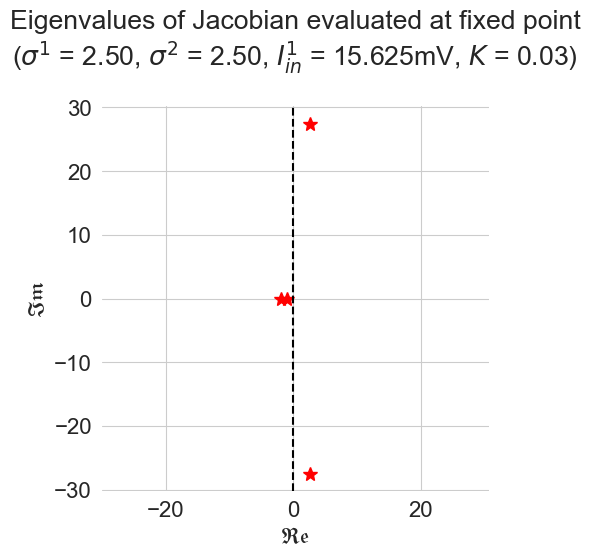

In [14]:
plt.figure(figsize=(5, 5))
for pos in ['right', 'top', 'bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)
        
plt.plot(eig_dict['eigvals'][0].real, eig_dict['eigvals'][0].imag, '*', markersize=10, color = 'r')
# plt.plot(eig_dict['eigvals'][1].real, eig_dict['eigvals'][1].imag, '*', markersize=10, color = 'b')
plt.axvline(x=0, color='k', linestyle='--')
plt.axis('equal')
plt.xlabel(r'$\mathfrak{Re}$');
plt.ylabel(r'$\mathfrak{Im}$')
plt.grid(True)
plt.title("Eigenvalues of Jacobian evaluated at fixed point\n" +\
          r"($\sigma^1$ = " + f"{params['sig_e1']:.2f}, " + r"$\sigma^2$ = " + f"{params['sig_e2']:.2f}, " + r"$I_{in}^1$ = " + f"{params['i_e1']:.3f}mV, " + r"$K$ = " + f"{params['K']})\n")
plt.show()

In [15]:
def wavelet_analysis(signals, t1, t2, center_freq = 12., fs = 1000, fig_size = (24, 8), if_plot = False):
    freq_arr = np.linspace(1, fs / 2, 2000)
    widths = center_freq * fs / (2 * freq_arr * np.pi)

    wtmatr = signal.cwt(signals[t1:t2] - np.mean(signals[t1:t2]), signal.morlet2, widths, w = center_freq)
    wtmatr = np.flipud(wtmatr)
    
    if if_plot:
        plt.figure(figsize = fig_size)
        plt.rcParams.update({'font.size': 30})
        plt.subplot(3, 2, 1)
        plt.plot(time_[t1:t2], signals[t1:t2])
        plt.xlabel('Time (au)')
        plt.ylabel(r'$U_e$')
        plt.title('Time Series')
    
        plt.subplot(1, 2, 2)
        plt.imshow(np.abs(wtmatr) / np.max(np.abs(wtmatr)), extent = [t1, t2, freq_arr[0], freq_arr[-1]], 
                   cmap = 'jet', aspect = 'auto')
        plt.colorbar()
        plt.ylabel('Freq. (Hz)')
        plt.xlabel('Time (au)')
        plt.title('Wavelet Analysis - Complex Morlet')
    
        plt.subplot(3, 2, 3)
        plt.specgram(signals[t1:t2], Fs = fs, cmap = 'jet')
        plt.xlabel('Time (au)')
        plt.ylabel('Freq. (Hz)')
        plt.title('STFT Analysis (PSD)')
        
        plt.subplot(3, 2, 5)
        plt.specgram(signals[t1:t2], Fs = fs, mode = 'phase', cmap = 'jet')
        plt.xlabel('Time (au)')
        plt.ylabel('Freq. (Hz)')
        plt.title('STFT Analysis (Phase)')
        
        for pos in ['right', 'top', 'bottom', 'left']:
           plt.gca().spines[pos].set_visible(False)
            
        # plt.suptitle(f'Time-Frequency Analysis for Node (N = 2 | K = {K})', fontsize = 45)
        plt.tight_layout()
        plt.show()
    
    return freq_arr, wtmatr / np.max(np.abs(wtmatr))

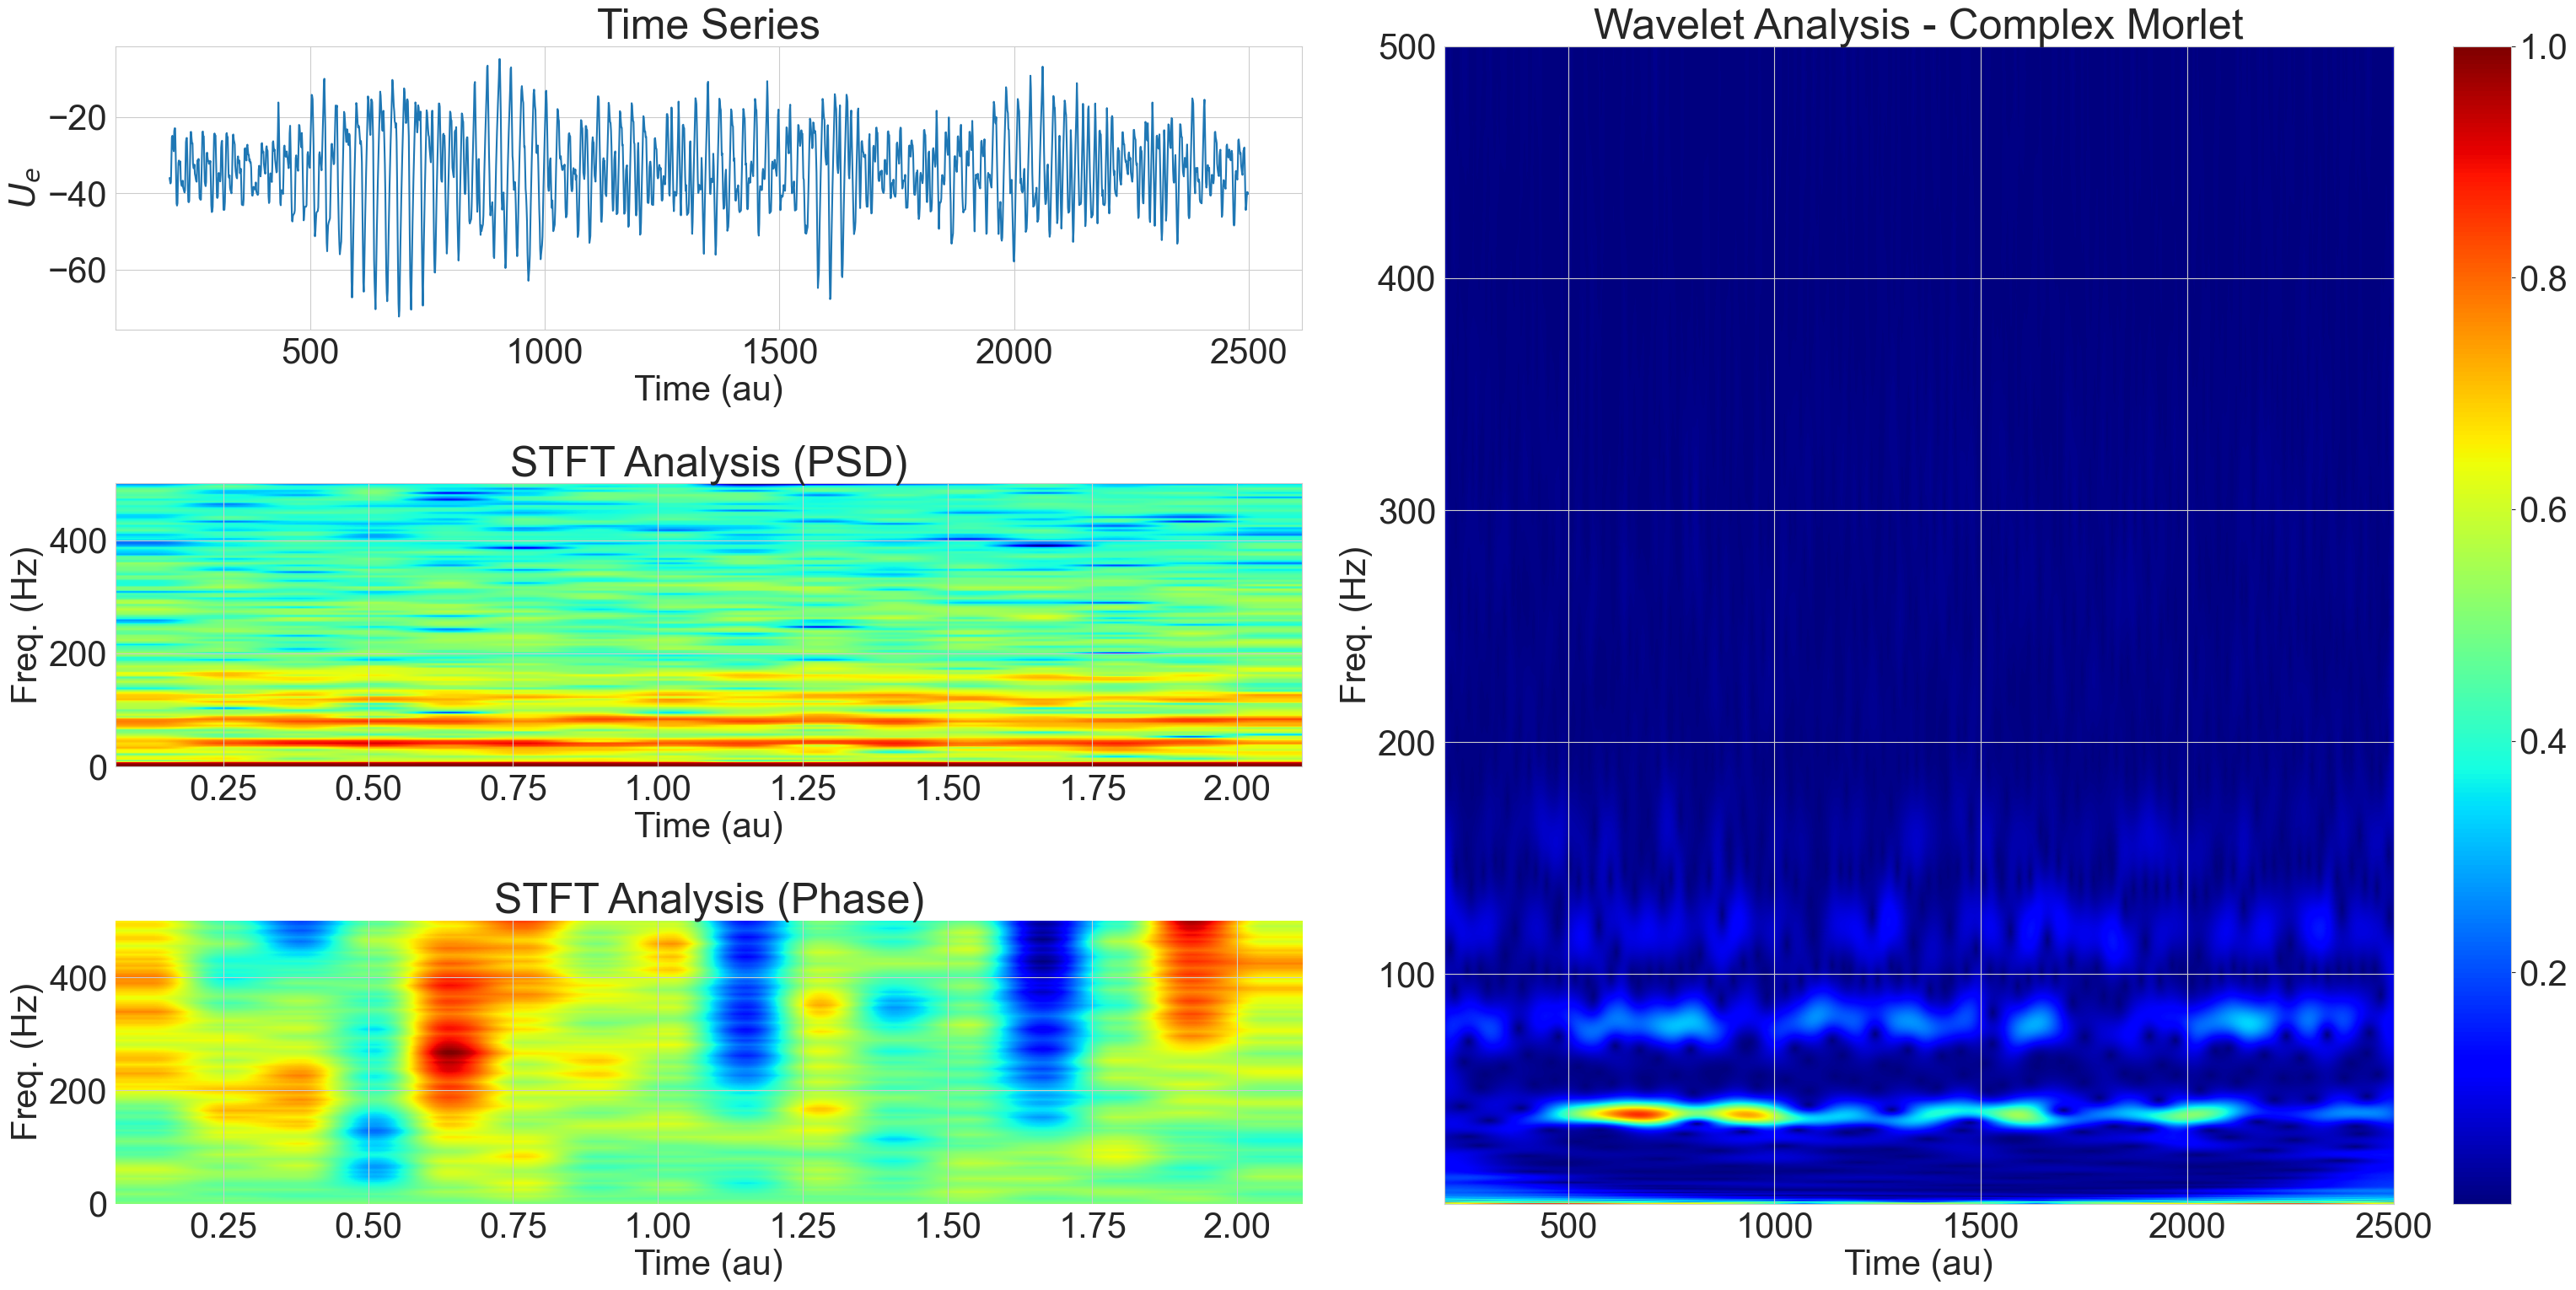

In [16]:
plot_bool = True
freq_arr, wt_matr = wavelet_analysis(np.mean(u[:, 0, :], axis=0), t1 = 200, t2 = T, center_freq = 12., fs = 1000, fig_size = (32, 16), if_plot = plot_bool)

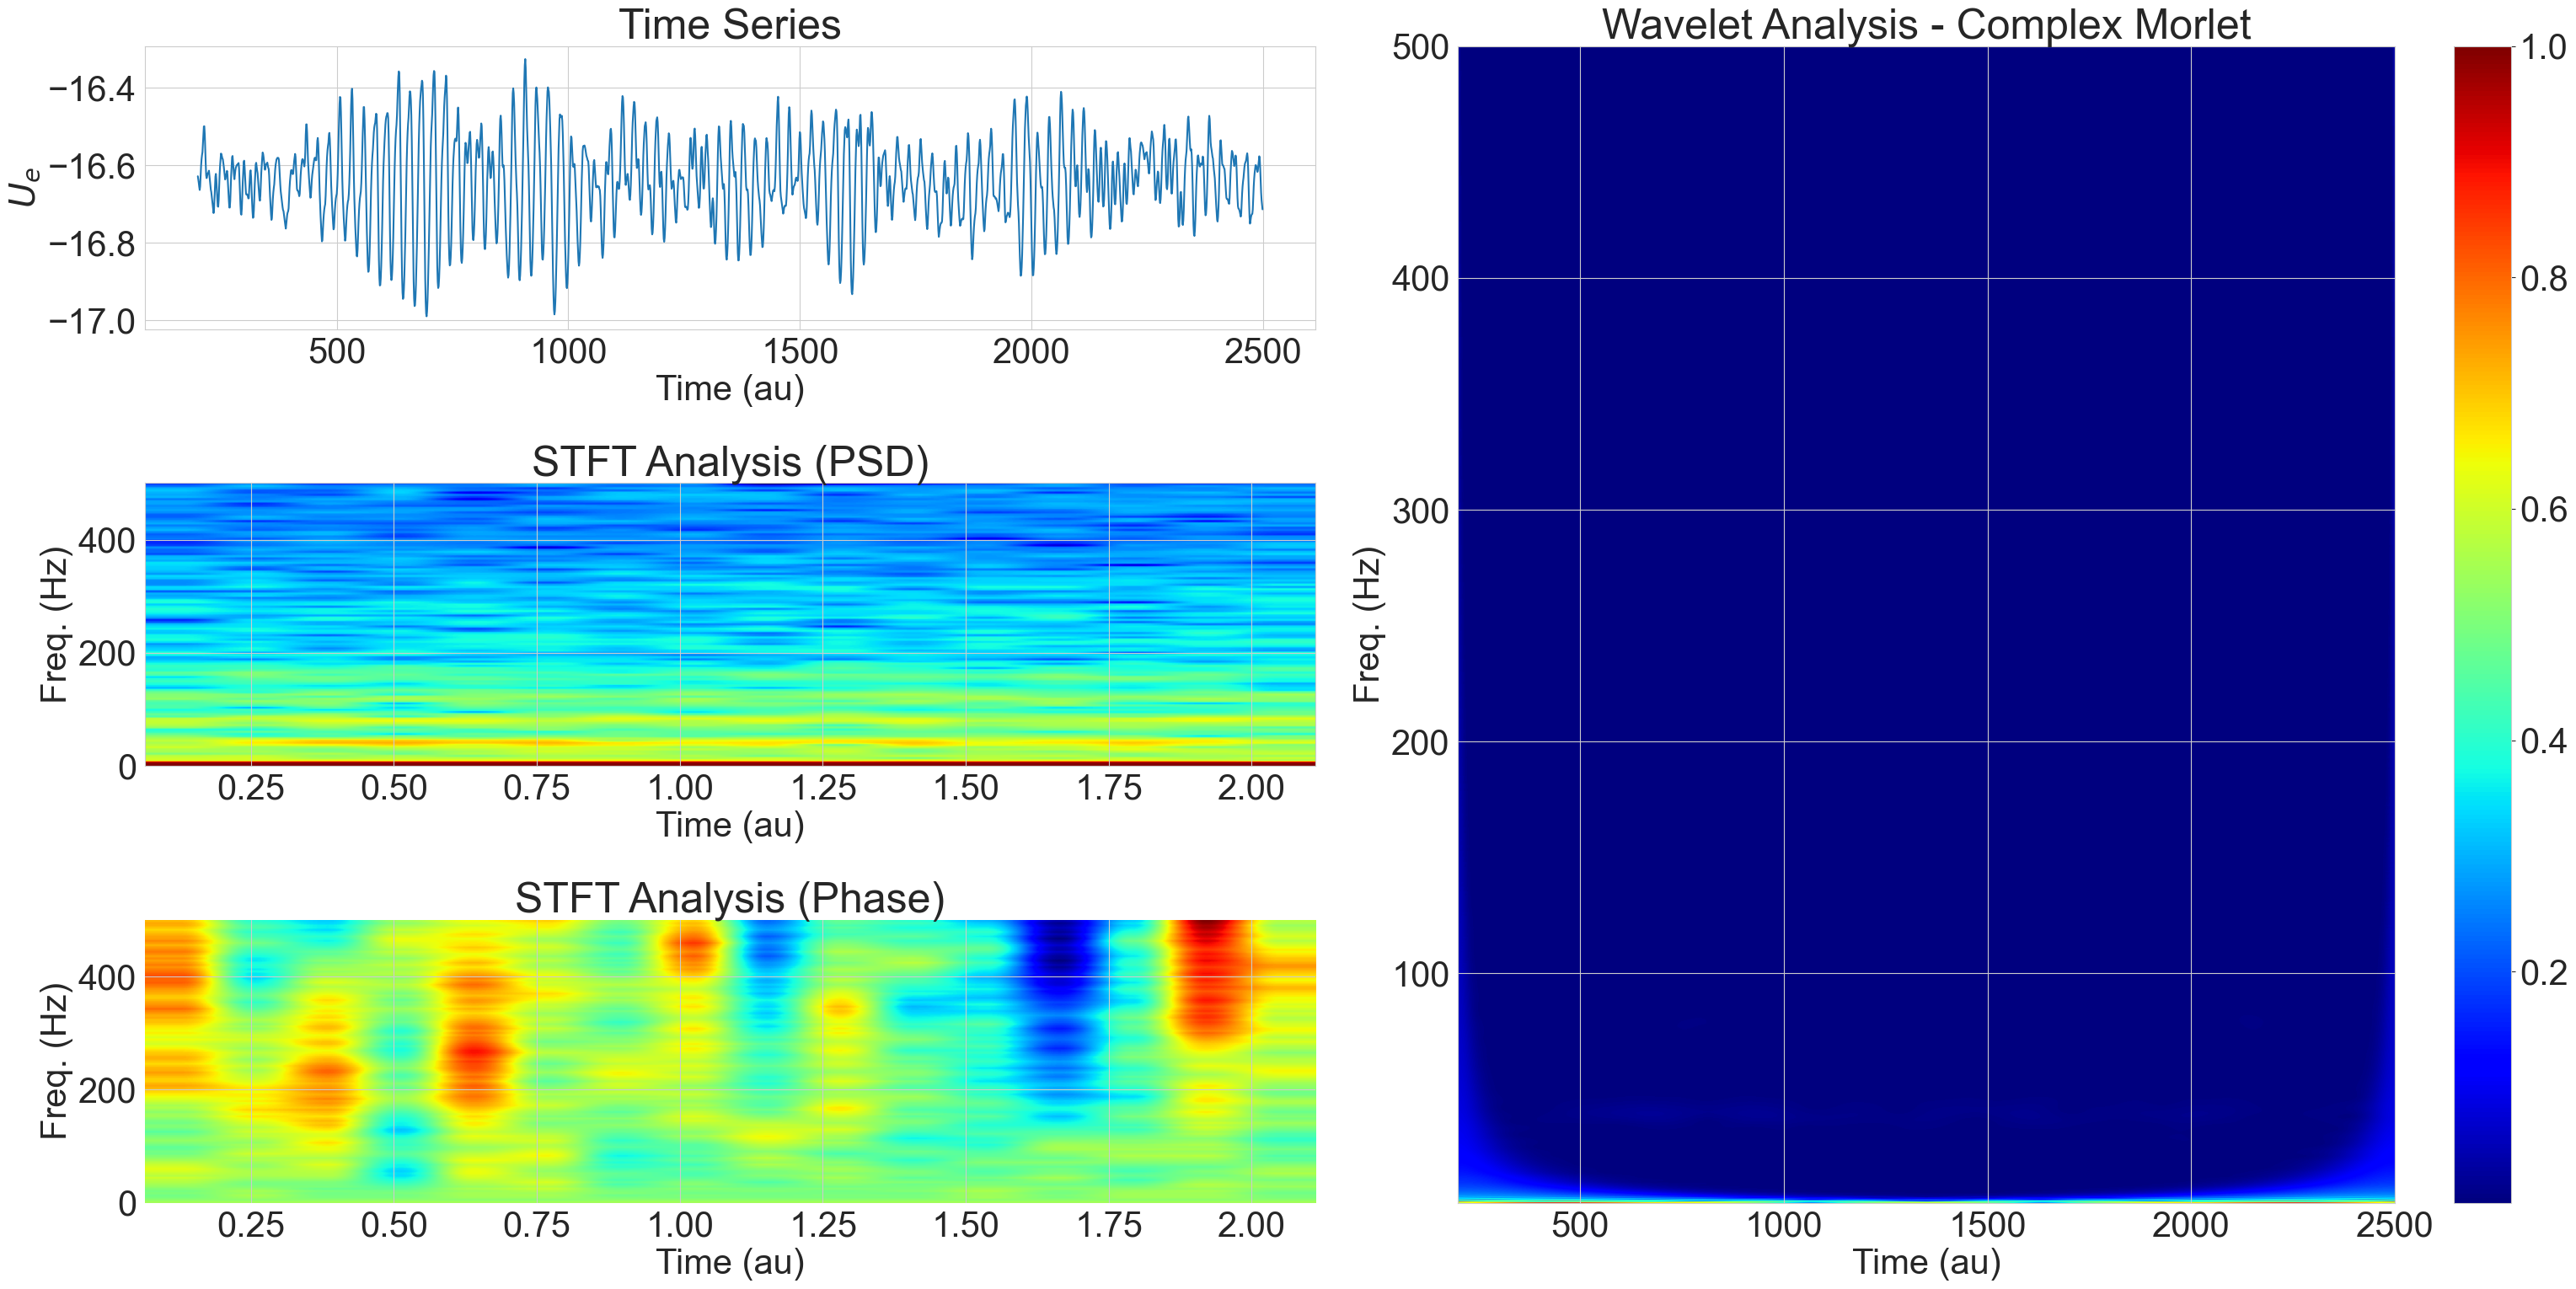

In [21]:
plot_bool = True
freq_arr2, wt_matr2 = wavelet_analysis(np.mean(u[:, 2, :], axis=0), t1 = 200, t2 = T, center_freq = 12., fs = 1000, fig_size = (32, 16), if_plot = plot_bool)

In [22]:
wt_matr = np.flipud(wt_matr)
wt_matr2 = np.flipud(wt_matr2)

In [23]:
fl = 80     # Hz
fh = 100    # Hz

ind_l = np.argmin(abs(freq_arr - fl)); print(ind_l)
ind_h = np.argmin(abs(freq_arr - fh)); print(ind_h)
    
band = wt_matr[ind_l:ind_h, :]
band_ind = np.argmax(np.abs(band), axis = 0)
wavelet_series1 = np.array([band[band_ind[k], k] for k in range(T - 200)])
phase_mat1 = np.exp(1j * np.unwrap(np.angle(wavelet_series1)))

band = wt_matr2[ind_l:ind_h, :]
band_ind = np.argmax(np.abs(band), axis = 0)
wavelet_series2 = np.array([band[band_ind[k], k] for k in range(T - 200)])
phase_mat2 = np.exp(1j * np.unwrap(np.angle(wavelet_series2))) 

316
397


In [24]:
np.abs(np.sum(np.abs(wavelet_series1) * np.abs(wavelet_series2) * (phase_mat1 / phase_mat2))) / len(phase_mat2)

0.0004922497082292663

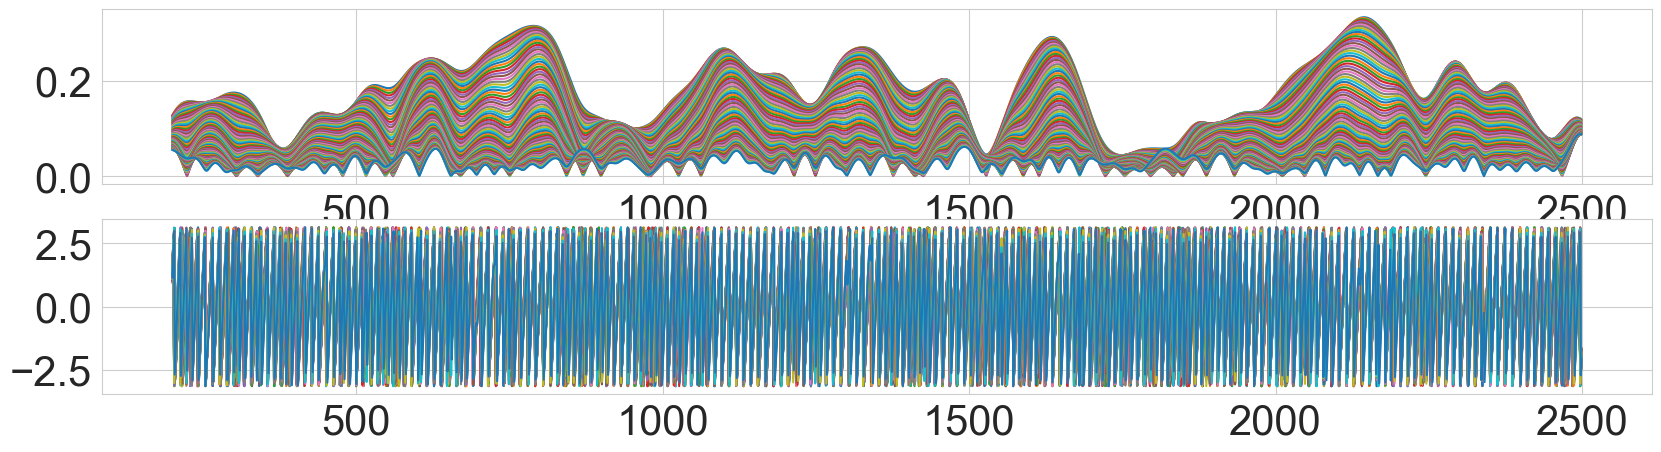

In [25]:
plt.figure(figsize=(20,5))
for i in range(ind_l, ind_h):
    plt.subplot(2, 1, 1)
    plt.plot(time_[200: ], abs(wt_matr[i, :]))
    plt.subplot(2, 1, 2)
    plt.plot(time_[200: ], np.angle(wt_matr[i, :]))

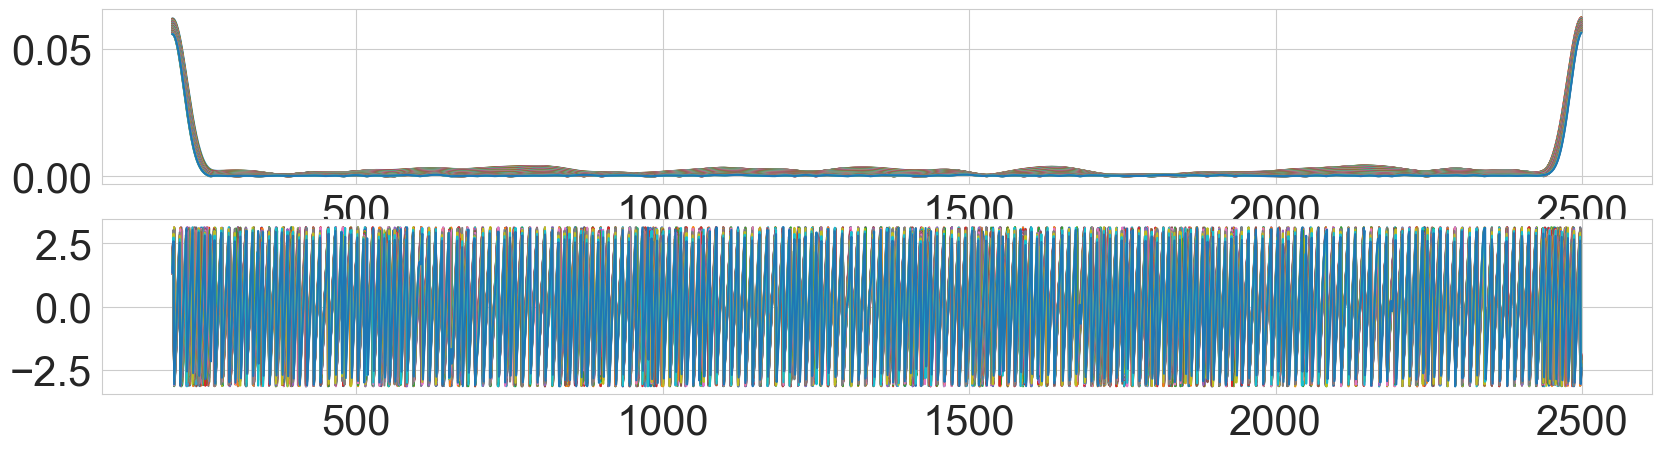

In [26]:
plt.figure(figsize=(20,5))
for i in range(ind_l, ind_h):
    plt.subplot(2, 1, 1)
    plt.plot(time_[200: ], abs(wt_matr2[i, :]))
    plt.subplot(2, 1, 2)
    plt.plot(time_[200: ], np.angle(wt_matr2[i, :]))

In [27]:
freq_arr[500]

125.81240620310155